# Image Captioning — Data & Training v4
**Architecture:** BLIP fine-tuned on Flickr8k  
**Changes from v3:**
- Removed image augmentation (disturbs BLIP's pre-trained input distribution)
- Removed two-phase unfreezing (caused destructive jump at epoch 4 in v3)
- Vision encoder stays frozen throughout (86M params, not needed for Flickr adaptation)
- Full decoder trains from epoch 1 at stable low LR (1e-5) with long warmup
- Added label smoothing ε=0.1 — clean regulariser that doesn't touch input distribution
- Longer patience (5) since training is now stable throughout


## 0. Install Dependencies

In [28]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

pip("transformers>=4.35", "accelerate")
print("Dependencies ready.")


Dependencies ready.


## 1. Imports & Setup

In [29]:
import os, re, math, json, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import BlipProcessor, BlipForConditionalGeneration

os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


PyTorch: 2.10.0+cu128
CUDA available: True
Device: cuda


## 2. Data Loading

In [30]:
import kagglehub

dataset_path = kagglehub.dataset_download('giorgicheishvili/caption-data')
dataset_path = Path(dataset_path)
print("Dataset root:", dataset_path)


Dataset root: /kaggle/input/datasets/giorgicheishvili/caption-data


In [31]:
IMAGES_DIR    = dataset_path / "Images"
CAPTIONS_FILE = dataset_path / "captions.txt"

if not IMAGES_DIR.exists():
    candidates = list(dataset_path.rglob("Images"))
    IMAGES_DIR = candidates[0] if candidates else dataset_path
if not CAPTIONS_FILE.exists():
    candidates = list(dataset_path.rglob("captions.txt"))
    CAPTIONS_FILE = candidates[0]

print("Images dir :", IMAGES_DIR)
print("Captions   :", CAPTIONS_FILE)
print("Image count:", len(list(IMAGES_DIR.glob("*.jpg"))))


Images dir : /kaggle/input/datasets/giorgicheishvili/caption-data/Images
Captions   : /kaggle/input/datasets/giorgicheishvili/caption-data/captions.txt
Image count: 8091


In [32]:
df = pd.read_csv(CAPTIONS_FILE)
df.columns = [c.strip() for c in df.columns]
df['image']   = df['image'].str.strip()
df['caption'] = df['caption'].str.strip()

print(f"Total rows   : {len(df)}")
print(f"Unique images: {df['image'].nunique()}")
df.head(6)


Total rows   : 40455
Unique images: 8091


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting


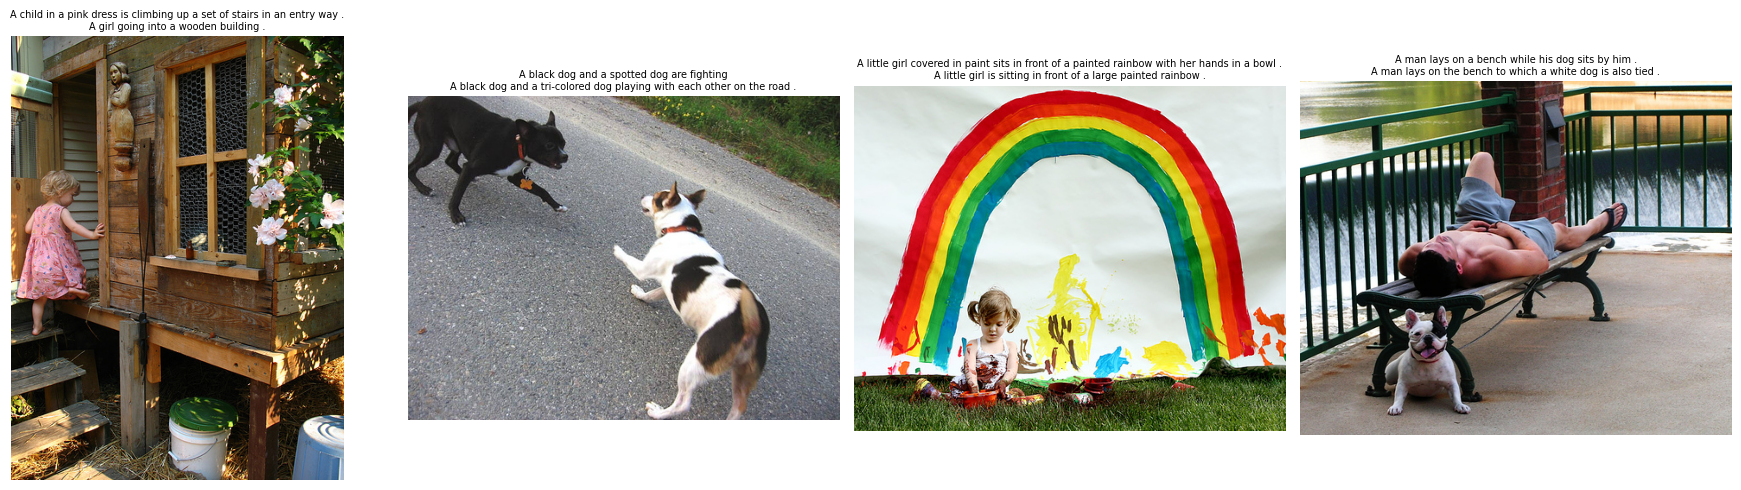

In [33]:
sample_imgs = df['image'].unique()[:4]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, img_name in zip(axes, sample_imgs):
    img      = Image.open(IMAGES_DIR / img_name).convert("RGB")
    captions = df[df['image'] == img_name]['caption'].tolist()
    ax.imshow(img)
    ax.set_title("\n".join(captions[:2]), fontsize=7, wrap=True)
    ax.axis('off')
plt.tight_layout(); plt.show()


## 3. Load BLIP Processor & Model

`Salesforce/blip-image-captioning-base` is pre-trained on 129M image-text pairs.  
The processor handles both image pre-processing and text tokenisation in one object.


In [34]:
MODEL_NAME = "Salesforce/blip-image-captioning-base"

processor = BlipProcessor.from_pretrained(MODEL_NAME)
model     = BlipForConditionalGeneration.from_pretrained(MODEL_NAME).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model          : {MODEL_NAME}")
print(f"Total params   : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Model          : Salesforce/blip-image-captioning-base
Total params   : 247,444,600
Trainable params: 247,444,600


## 4. Train / Validation Split

In [35]:
all_images = df['image'].unique().tolist()
random.shuffle(all_images)

split      = int(0.90 * len(all_images))
train_imgs = set(all_images[:split])
val_imgs   = set(all_images[split:])

train_df = df[df['image'].isin(train_imgs)].reset_index(drop=True)
val_df   = df[df['image'].isin(val_imgs)].reset_index(drop=True)

print(f"Train rows: {len(train_df)}  ({train_df['image'].nunique()} images)")
print(f"Val   rows: {len(val_df)}   ({val_df['image'].nunique()} images)")


Train rows: 36405  (7281 images)
Val   rows: 4050   (810 images)


## 5. Dataset & DataLoader

In [36]:
class FlickrDataset(Dataset):
    """
    Each training sample is one (image, caption) pair.
    During training we randomly pick one of the 5 captions per image.
    During validation we use all captions (one row per caption).
    No image augmentation — BLIP's visual encoder is sensitive to its
    pre-trained input distribution; augmentation hurt performance in v3.
    """
    def __init__(self, dataframe, images_dir, processor, augment_captions=False):
        self.df               = dataframe.reset_index(drop=True)
        self.images_dir       = Path(images_dir)
        self.processor        = processor
        self.augment_captions = augment_captions

        self.unique_images   = self.df["image"].unique().tolist()
        self.img_to_captions = (
            self.df.groupby("image")["caption"].apply(list).to_dict()
        )

    def __len__(self):
        return len(self.unique_images) if self.augment_captions else len(self.df)

    def __getitem__(self, idx):
        if self.augment_captions:
            img_name = self.unique_images[idx]
            caption  = random.choice(self.img_to_captions[img_name])
        else:
            row      = self.df.iloc[idx]
            img_name = row["image"]
            caption  = row["caption"]

        image = Image.open(self.images_dir / img_name).convert("RGB")
        return image, caption


def collate_fn(batch):
    images, captions = zip(*batch)
    encoding = processor(
        images=list(images),
        text=list(captions),
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=64,
    )
    labels = encoding["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    encoding["labels"] = labels
    return encoding


BATCH_SIZE  = 16
NUM_WORKERS = 2

train_dataset = FlickrDataset(train_df, IMAGES_DIR, processor, augment_captions=True)
val_dataset   = FlickrDataset(val_df,   IMAGES_DIR, processor, augment_captions=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")


Train batches : 456
Val   batches : 254


## 6. Training

### Strategy
- **Vision encoder frozen throughout** — 86M params that don't need to change for Flickr.
- **Full text decoder trains from epoch 1** at a conservative LR (1e-5) — stable, no
  destructive jump like the two-phase approach in v3.
- **Long warmup (2 epochs)** — lets the decoder settle before LR reaches its peak.
- **Label smoothing ε=0.1** — prevents overconfidence on any single caption phrasing,
  acts as regulariser without touching the input distribution.
- **Gradient accumulation** × 4 → effective batch of 64.
- **Mixed precision** (FP16).
- **Early stopping** patience=5.


In [37]:
ACCUM_STEPS   = 4
NUM_EPOCHS    = 20
WARMUP_EPOCHS = 2
PATIENCE      = 5
LABEL_SMOOTH  = 0.1

# Freeze vision encoder — it doesn't need to change for Flickr8k adaptation
for p in model.vision_model.parameters():
    p.requires_grad = False

# Everything else (full text decoder) trains from epoch 1
for p in model.text_decoder.parameters():
    p.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f"Trainable params : {trainable:,}")
print(f"Frozen params    : {frozen:,}  (vision encoder)")

# Deduplicate params (BLIP has tied weights)
seen, unique_params = set(), []
for p in model.parameters():
    if p.requires_grad and id(p) not in seen:
        unique_params.append(p)
        seen.add(id(p))

optimizer = torch.optim.AdamW(
    unique_params,
    lr=1e-5,           # conservative — full decoder fine-tuning needs low LR
    weight_decay=1e-2,
    betas=(0.9, 0.98),
)

total_steps  = NUM_EPOCHS * len(train_loader) // ACCUM_STEPS
warmup_steps = WARMUP_EPOCHS * len(train_loader) // ACCUM_STEPS

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.05, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.amp.GradScaler("cuda")

print(f"Total update steps : {total_steps}")
print(f"Warmup steps       : {warmup_steps}")
print(f"Label smoothing    : {LABEL_SMOOTH}")


Trainable params : 161,354,104
Frozen params    : 86,090,496  (vision encoder)
Total update steps : 2280
Warmup steps       : 228
Label smoothing    : 0.1


In [38]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*lr_scheduler.*")


def smooth_loss(logits, labels, smoothing=0.1, ignore_index=-100):
    """
    Cross-entropy with label smoothing.
    Distributes `smoothing` probability mass uniformly across all vocab tokens,
    reducing overconfidence on a single caption phrasing.
    """
    vocab_size = logits.size(-1)
    # Shift for next-token prediction
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()

    mask = (shift_labels != ignore_index)

    # Standard log-softmax
    log_probs = torch.nn.functional.log_softmax(shift_logits, dim=-1)

    # Hard target loss
    nll = -log_probs.gather(dim=-1, index=shift_labels.clamp(min=0).unsqueeze(-1)).squeeze(-1)
    # Smooth target: uniform over entire vocab
    smooth = -log_probs.sum(dim=-1) / vocab_size

    loss = (1 - smoothing) * nll + smoothing * smooth
    return loss[mask].mean()


def train_one_epoch(model, loader, optimizer, scheduler, scaler, device, accum_steps):
    model.train()
    total_loss, n_batches        = 0.0, 0
    correct_tokens, total_tokens = 0, 0
    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}

        with torch.amp.autocast("cuda"):
            outputs = model(**batch)
            # Replace BLIP's built-in loss with label-smoothed version
            loss = smooth_loss(outputs.logits, batch["labels"],
                               smoothing=LABEL_SMOOTH) / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        with torch.no_grad():
            shift_logits = outputs.logits[:, :-1, :].contiguous()
            shift_labels = batch["labels"][:, 1:].contiguous()
            preds = shift_logits.argmax(dim=-1)
            mask  = (shift_labels != -100)
            correct_tokens += (preds[mask] == shift_labels[mask]).sum().item()
            total_tokens   += mask.sum().item()
            total_loss     += loss.item() * accum_steps
            n_batches      += 1

    optimizer.zero_grad()
    return total_loss / max(n_batches, 1), correct_tokens / max(total_tokens, 1)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, n_batches        = 0.0, 0
    correct_tokens, total_tokens = 0, 0

    for batch in loader:
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
        with torch.amp.autocast("cuda"):
            outputs = model(**batch)
            loss = smooth_loss(outputs.logits, batch["labels"], smoothing=LABEL_SMOOTH)

        shift_logits = outputs.logits[:, :-1, :].contiguous()
        shift_labels = batch["labels"][:, 1:].contiguous()
        preds = shift_logits.argmax(dim=-1)
        mask  = (shift_labels != -100)
        correct_tokens += (preds[mask] == shift_labels[mask]).sum().item()
        total_tokens   += mask.sum().item()
        total_loss     += loss.item()
        n_batches      += 1

    return total_loss / n_batches, correct_tokens / max(total_tokens, 1)


In [39]:
SAVE_DIR = Path("/kaggle/working")
SAVE_DIR.mkdir(exist_ok=True)

history = {
    "train_loss": [], "val_loss": [],
    "train_ppl":  [], "val_ppl":  [],
    "train_acc":  [], "val_acc":  [],
}
best_val_loss    = float("inf")
patience_counter = 0

print(f"{'Epoch':>6}  {'Tr Loss':>8}  {'Tr PPL':>7}  {'Tr Acc':>7}  {'Val Loss':>9}  {'Val PPL':>8}  {'Val Acc':>8}  {'Time':>6}")
print("-" * 85)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler, DEVICE, ACCUM_STEPS
    )
    val_loss, val_acc = evaluate(model, val_loader, DEVICE)

    train_ppl = math.exp(min(train_loss, 20))
    val_ppl   = math.exp(min(val_loss,   20))
    elapsed   = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_ppl"].append(train_ppl)
    history["val_ppl"].append(val_ppl)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"{epoch:>6}  {train_loss:>8.4f}  {train_ppl:>7.2f}  {train_acc:>6.2%}  "
          f"{val_loss:>9.4f}  {val_ppl:>8.2f}  {val_acc:>7.2%}  {elapsed:>5.0f}s")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        model.save_pretrained(str(SAVE_DIR / "best_model"))
        processor.save_pretrained(str(SAVE_DIR / "best_model"))
        print(f"         ✓ New best saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print("\nTraining complete.")
print(f"Best val loss : {best_val_loss:.4f}  |  Best val PPL: {math.exp(min(best_val_loss,20)):.2f}")


 Epoch   Tr Loss   Tr PPL   Tr Acc   Val Loss   Val PPL   Val Acc    Time
-------------------------------------------------------------------------------------
     1    3.9845    53.76  46.48%     3.7702     43.39   48.68%    250s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=3.7702)
     2    3.6694    39.23  49.55%     3.5665     35.39   49.53%    252s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=3.5665)
     3    3.4294    30.86  50.31%     3.3300     27.94   50.26%    252s


...

         ✓ New best saved (val_loss=3.0044)
    19    2.8583    17.43  59.10%     3.0042     20.17   56.13%    251s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=3.0042)
    20    2.8441    17.19  59.28%     3.0039     20.16   56.15%    252s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=3.0039)

Training complete.
Best val loss : 3.0039  |  Best val PPL: 20.16


## 7. Training Curves

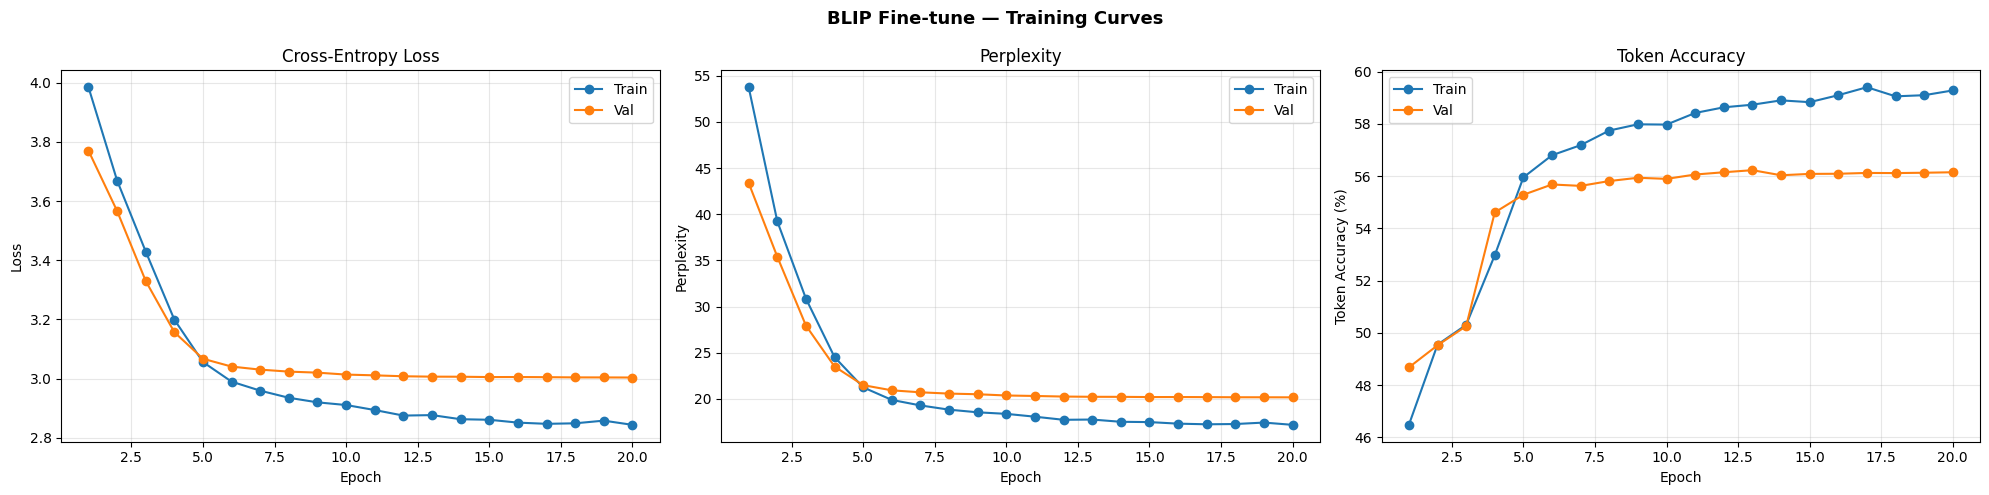

In [43]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(epochs_ran, history["train_loss"], label="Train", marker="o")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val",   marker="o")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Cross-Entropy Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history["train_ppl"], label="Train", marker="o")
axes[1].plot(epochs_ran, history["val_ppl"],   label="Val",   marker="o")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_ran, [a * 100 for a in history["train_acc"]], label="Train", marker="o")
axes[2].plot(epochs_ran, [a * 100 for a in history["val_acc"]],   label="Val",   marker="o")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Token Accuracy (%)")
axes[2].set_title("Token Accuracy"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle("BLIP Fine-tune — Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Caption Preview

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


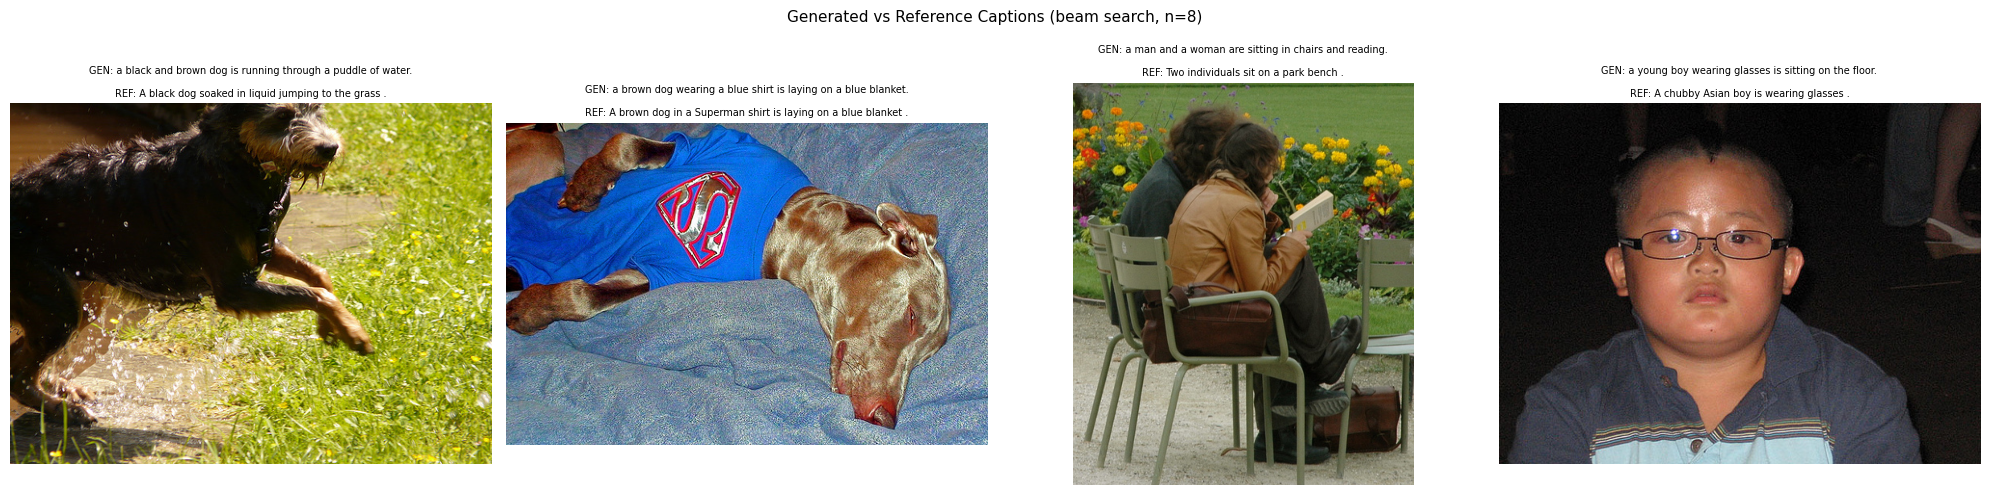

In [41]:
from transformers import BlipForConditionalGeneration as _BLIP

best_model     = _BLIP.from_pretrained(str(SAVE_DIR / 'best_model')).to(DEVICE)
best_processor = BlipProcessor.from_pretrained(str(SAVE_DIR / 'best_model'))
best_model.eval()

@torch.no_grad()
def generate_caption(image_path: str, model=best_model) -> str:
    """
    Takes a path to an image and returns a generated caption string.
    """
    image   = Image.open(image_path).convert("RGB")
    inputs  = best_processor(images=image, return_tensors="pt").to(DEVICE)
    out_ids = model.generate(**inputs, max_new_tokens=40, num_beams=8)
    return best_processor.decode(out_ids[0], skip_special_tokens=True)


sample_rows = val_df.drop_duplicates('image').sample(4, random_state=SEED)
fig, axes   = plt.subplots(1, 4, figsize=(20, 5))

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = str(IMAGES_DIR / row['image'])
    caption  = generate_caption(img_path)
    ref_caps = val_df[val_df['image'] == row['image']]['caption'].tolist()

    ax.imshow(Image.open(img_path))
    ax.set_title(f"GEN: {caption}\n\nREF: {ref_caps[0]}", fontsize=7, wrap=True)
    ax.axis('off')

plt.suptitle('Generated vs Reference Captions (beam search, n=8)', fontsize=11)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'caption_examples.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. BLEU-4 Evaluation

Compute BLEU-4 on the validation set — the standard metric for captioning on Flickr8k.  
Each generated caption is compared against all 5 human references for that image.


In [42]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "nltk"])
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

best_model.eval()
val_images = val_df['image'].unique().tolist()

all_references = []
all_hypotheses = []

print(f"Evaluating BLEU-4 on {len(val_images)} validation images...")

for i, img_name in enumerate(val_images):
    img_path = str(IMAGES_DIR / img_name)
    caption  = generate_caption(img_path)

    refs = val_df[val_df['image'] == img_name]['caption'].tolist()
    ref_tokens  = [r.lower().split() for r in refs]
    hyp_tokens  = caption.lower().split()

    all_references.append(ref_tokens)
    all_hypotheses.append(hyp_tokens)

    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(val_images)} done...")

smoother = SmoothingFunction().method1
bleu4 = corpus_bleu(all_references, all_hypotheses,
                    weights=(0.25, 0.25, 0.25, 0.25),
                    smoothing_function=smoother)

print(f"\nBLEU-4 on validation set: {bleu4 * 100:.2f}")


Evaluating BLEU-4 on 810 validation images...
  100/810 done...
  200/810 done...
  300/810 done...
  400/810 done...
  500/810 done...
  600/810 done...
  700/810 done...
  800/810 done...

BLEU-4 on validation set: 29.84


## 10. Save Artifacts

In [44]:
with open(SAVE_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f)

print("Artifacts in:", SAVE_DIR)
print("  best_model/            — BLIP weights + processor (use with from_pretrained)")
print("  training_curves.png    — loss & perplexity plots")
print("  caption_examples.png   — sample generated captions")
print("  training_history.json  — per-epoch metrics")


Artifacts in: /kaggle/working
  best_model/            — BLIP weights + processor (use with from_pretrained)
  training_curves.png    — loss & perplexity plots
  caption_examples.png   — sample generated captions
  training_history.json  — per-epoch metrics
